# KI - Von Algorithmen zu Altagshelfern
## Mit Vibe Coding zu einer verbesserten Datenqualität
### Workshop 28.05.2026

<br>

***Infos zu dieser Datei:***

*Das hier ist ein Jupyter Notebook. Ein Jupyter Notebook ist eine interaktive Entwicklungsumgebung, die aus verschiedenen Zellen besteht.*

*Diese Zellen können unterschiedliche Typen haben. Diese Zelle zum Beispiel enthält Text, man nennt sie "Markdown" Zelle. Zellen wie die nächste sind "Code"-Zellen - dort kann Python Code hineingeschrieben werden. Damit der Code in den Code-Zellen ausgeführt wird, müsst ihr eine Zelle auswählen und den "Pfeil"-Knopf in der oberen Leiste klicken. Alternativ könnt ihr mit dem "doppelten Pfeil"-Knopf alle Zellen ausführen.*

*Wenn eine Code-Zelle ausgeführt wird, erscheint unter der Zelle der Output (das Ergebnis) der Zelle.*

<br>

**Was können wir mit dieser Datei machen?**

Im Folgenden wollen wir uns Schritt für Schritt anschauen, wie wir einen Datensatz mithilfe von Python-Code bereinigen, erste kleine Auswertungen durchführen und Visualisierungen generieren können.



### Arbeitspakete (sog. "Python packages") laden

In Python sind Packages (Pakete) Sammlungen von fertigem Code, die du in deinem Projekt verwenden kannst. Sie sparen dir Arbeit, weil du Funktionen nicht selbst programmieren musst. 

In [80]:
# Import notwendiger Arbeitspakete
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as mticker
from wordcloud import WordCloud

### Daten Exploration

Bevor wir mit der Datenbereinigung beginnen, ist es sinnvoll, sich einen guten Überblick über den vorliegenden Datensatz zu machen.

In [ ]:
# Datensatz einlesen und erste 10 Zeilen anzeigen
df = pd.read_csv('./beispiel-datensatz.csv', sep=',')
df.head(10)

,Name,Alter,Geschlecht,Email,Adresse,PLZ,Stadt,Bildungsabschluss,Erster Kontakt mit Organisation,Weiterempfehlung,Erneute Teilnahme,Austausch nach Programmende,Zufriedenheit Organisation,Zufriedenheit Zuteilung,Meiste Freude,Ein Wort
0,Peter Demir,16,männlich,peter.demir@example.com,Sonnenallee 12,12045,Berlin,Mittlere Reife,ja,auf jeden Fall,"ja, als Mentee",ja,9.0,10.0,neue Menschen kennenzulernen,inspirierend
1,Samir Yilmaz,18,männlich,samir.yilmaz@example.com,Kantstraße 44,10625,berlin,Abitur,nein,eher ja,"ja, als Mentor",ja,8.0,9.0,gemeinsame Aktivitäten,motivierend
2,Lea Hassan,15,weiblich,lea.hassan@example.com,Hafenweg 7,45127,Essen,Hauptschulabschluss,ja,auf jeden Fall,"ja, als Mentee",ja,10.0,9.0,neue Fertigkeiten zu lernen,stärkend
3,Deniz Kara,20,männlich,deniz.kara@example.com,Marktplatz 21,44135,Dortmund,Fachabitur,nein,auf jeden Fall,"ja, als Mentor",ja,9.0,10.0,gemeinsames Lernen,hilfreich
4,Mina Özdemir,17,weiblich,mina.oezdemir@example.com,Lindenstraße 9,50667,Köln,Mittlere Reife,ja,eher ja,"ja, als Mentee",nein,8.0,8.0,neue Dinge auszuprobieren,spannend
5,Yusuf Arslan,19,männlich,yusuf.arslan@example.com,Bergweg 5,20095,Hamburg,Abitur,nein,auf jeden Fall,"ja, als Mentor",ja,10.0,10.0,gemeinsame Aktivitäten,bereichernd
6,Sara Mert,14,weiblich,sara.mert@example.com,Goethestraße 31,60311,Frankfurt am Main,Noch kein Abschluss,ja,auf jeden Fall,"ja, als Mentee",ja,9.0,9.0,neue Menschen kennenzulernen,ermutigend
7,Can Polat,21,männlich,can.polat@example.com,Hauptstraße 18,90402,Nürnberg,Bachelor,nein,eher ja,nein,nein,7.0,8.0,gemeinsames Lernen,wertvoll
8,Amira Said,16,divers,amira.said@example.com,Schillerweg 14,28195,Bremen,Mittlere Reife,ja,auf jeden Fall,"ja, als Mentee",ja,10.0,9.0,neue Fertigkeiten zu lernen,familiär
9,Paula Frantz,18,weiblich,paula.frantz@example.com,Ringstraße 3,70173,Stuttgart,Fachabitur,nein,eher ja,"ja, als Mentor",ja,8.0,8.0,gemeinsame Aktivitäten,positiv


In [ ]:
# Anzahl der (Zeilen, Spalten) des Datensatzes anzeigen
print(df.shape)

(103, 16)


In [83]:
# Spaltennamen anzeigen
print(df.columns)

Index(['Name', 'Alter', 'Geschlecht', 'Email', 'Adresse', 'PLZ', 'Stadt',
       'Bildungsabschluss', 'Erster Kontakt mit Organisation',
       'Weiterempfehlung', 'Erneute Teilnahme', 'Austausch nach Programmende',
       'Zufriedenheit Organisation', 'Zufriedenheit Zuteilung',
       'Meiste Freude', 'Ein Wort'],
      dtype='object')


In [84]:
# Datentypen der Spalten anzeigen und fehlende Werte zählen
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Name                             103 non-null    object 
 1   Alter                            103 non-null    int64  
 2   Geschlecht                       103 non-null    object 
 3   Email                            103 non-null    object 
 4   Adresse                          103 non-null    object 
 5   PLZ                              103 non-null    int64  
 6   Stadt                            103 non-null    object 
 7   Bildungsabschluss                102 non-null    object 
 8   Erster Kontakt mit Organisation  102 non-null    object 
 9   Weiterempfehlung                 102 non-null    object 
 10  Erneute Teilnahme                102 non-null    object 
 11  Austausch nach Programmende      102 non-null    object 
 12  Zufriedenheit Organisa

In [ ]:
# Zeilen ausgeben, in denen Null-Werte vorkommen, dabei die folgenden Spalten anzeigen: Name und Email
print(df[df.isnull().any(axis=1)][['Name', 'Email']])

                 Name                    Email
26  Franz Peter Wolff  franz.wolff@example.com


In [86]:
# Zufammenfassung der numerischen Spalten anzeigen
df.select_dtypes(include=[np.number]).describe().T

,count,mean,std,min,25%,50%,75%,max
Alter,103.0,17.582524,2.102866,14.0,16.0,17.0,19.0,21.0
PLZ,103.0,49671.660194,23941.705962,1067.0,34118.0,50667.0,68160.0,93051.0
Zufriedenheit Organisation,102.0,8.784314,1.086619,5.0,8.0,9.0,10.0,10.0
Zufriedenheit Zuteilung,102.0,8.941176,0.962912,6.0,8.0,9.0,10.0,10.0


In [ ]:
# Alle Zeilen ausgeben, die einen Wert in der Spalte "PLZ" haben, dessen Länge < 5 Zeichen hat.
# Dabei die folgenden Spalten anzeigen: PLZ und Stadt
print(df[df['PLZ'].astype(str).str.len() < 5][['PLZ', 'Stadt']])

     PLZ    Stadt
11  1067  Dresden
12  4109  Leipzig
47  1069  Dresden
48  4107  Leipzig
82  1097  Dresden
83  4155  Leipzig


In [ ]:
# Kategorische Spalten analysieren - Häufigkeiten für die Spalte "Stadt" ausgeben.
# Die Ausgabe soll alphabetisch sortiert sein.  
kats = ["Stadt"]
for col in kats:
    print(df[col].value_counts(dropna=False).sort_index())
    print()

Stadt
aachen               2
augsburg             3
berlin               2
bochum               2
bonn                 3
bremen               3
dortmund             1
dresden              3
duisburg             3
essen                3
frankfurt am main    3
freiburg             3
hamburg              6
hannover             1
heilbronn            3
karlsruhe            2
kassel               3
kiel                 3
köln                 3
leipzig              3
magdeburg            3
mainz                3
mannheim             3
münchen              3
nürnberg             3
oberhausen           2
offenbach            3
osnabrück            3
potsdam              2
regensburg           3
rostock              1
saarbrücken          2
siegen               3
stuttgart            3
trier                3
wolfsburg            2
wuppertal            3
Name: count, dtype: int64



In [97]:
# Dubletten finden: Zeilen, die in allen Spalten identisch sind.
# Ausgeben der doppelten Zeilen, dabei die folgenden Spalten anzeigen: Name und Email
duplicates = df[df.duplicated()]
print(duplicates[['Name', 'Email']])

Empty DataFrame
Columns: [Name, Email]
Index: []


In [ ]:
# Dubletten finden: Zeilen, für die der Wert in der Spalte "Email" identisch ist.
# Ausgeben der doppelten Zeilen, dabei die folgenden Spalten anzeigen: Name und Email
email_duplicates = df[df.duplicated(subset=['Email'])]
print(email_duplicates[['Name', 'Email']])

             Name                      Email
27    Franz Wolff    franz.wolff@example.com
80   Mina Özdemir  mina.oezdemir@example.com
102       Maja B.     maja.biene@example.com


### Datenbereinigung

Nachdem wir uns einen guten Überblick über den Datensatz verschafft haben und die Fehlstellen kennen, können wir diese nun beheben und den bereinigten Datensatz in einer neuen Datei speichern.

In [ ]:
# 1) E-Mail-Dubletten: bei gleichen Email-Einträgen die "vollständigere" Zeile behalten.
# Definition "vollständiger": mehr nicht-leere Felder (höhere Anzahl ausgefüllter Werte).
def non_empty_count(row):
    return row.notna().sum()

# Sortiere so, dass bei gleicher Email die Zeile mit mehr ausgefüllten Werten zuerst kommt,
# und falls gleich, bleibt die erste (keep='first' nach sortieren).
df = df.copy()
df["_non_empty"] = df.apply(non_empty_count, axis=1)
df = df.sort_values(by=["Email", "_non_empty"], ascending=[True, False])
df = df.drop_duplicates(subset=["Email"], keep="first").drop(columns=["_non_empty"])

# 2) Fehlende Werte entfernen (vollständige Zeilen behalten nur, keine NaNs)
df = df.dropna(how="any").reset_index(drop=True)

# 3) PLZ in Text umwandeln und mit führender Null auf 5 Stellen bringen (bei kürzeren Einträgen).
# Zuerst als String, entfernen von nicht-numerischen Zeichen, dann links mit '0' auffüllen.
df["PLZ"] = df["PLZ"].astype(str).str.replace(r"[^0-9]", "", regex=True).str.zfill(5)

# 4) Stadt kleinschreiben
df["Stadt"] = df["Stadt"].astype(str).str.lower()

# 5) Einträge in der Spalte "Ein Wort" kleinschreiben
df["Ein Wort"] = df["Ein Wort"].astype(str).str.lower()

# Ergebnis speichern (Komma als Trenner)
df.to_csv("datensatz-clean.csv", index=False, sep=",")

### Datenanalyse

Nachdem wir den Datensatz bereinigt haben, können wir nun mit der Analyse und Visualisierung der Daten starten...

In [98]:
# Kategoriale Spalten analysieren - relative Häufigkeiten: Geschlecht und Bildungsabschluss
kats = ["Geschlecht", "Bildungsabschluss"]
for col in kats:
    print(col)
    #print(df[col].value_counts(dropna=False))
    print(df[col].value_counts(normalize=True).round(3))  # relative Häufigkeiten
    print()

Geschlecht
Geschlecht
männlich    0.53
weiblich    0.45
divers      0.02
Name: proportion, dtype: float64

Bildungsabschluss
Bildungsabschluss
Mittlere Reife         0.31
Abitur                 0.22
Noch kein Abschluss    0.18
Fachabitur             0.16
Bachelor               0.12
Hauptschulabschluss    0.01
Name: proportion, dtype: float64



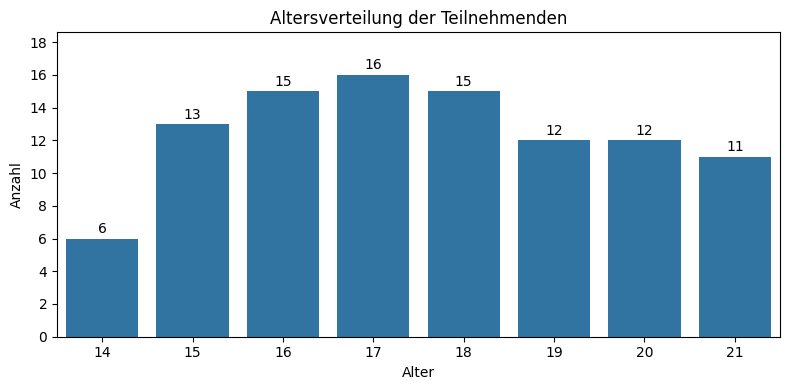

In [102]:
# Altersverteilung der Teilnehmenden visualisieren: Balkendiagramm mit Alter auf der x-Achse und Anzahl auf der y-Achse

# Häufigkeiten pro Alter
age_index = list(range(14, 22))
counts = df["Alter"].value_counts().reindex(age_index, fill_value=0).sort_index()

# Plot
plt.figure(figsize=(8,4))
sns.barplot(x=list(counts.index), y=counts.values)
plt.xlabel("Alter")
plt.ylabel("Anzahl")
plt.title("Altersverteilung der Teilnehmenden")
plt.ylim(0, counts.values.max() * 1.1 + 1)

# Werte über Balken
for i, v in enumerate(counts.values):
    plt.text(i, v + max(counts.values)*0.02 + 0.01, str(v), ha="center")

ax = plt.gca()
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

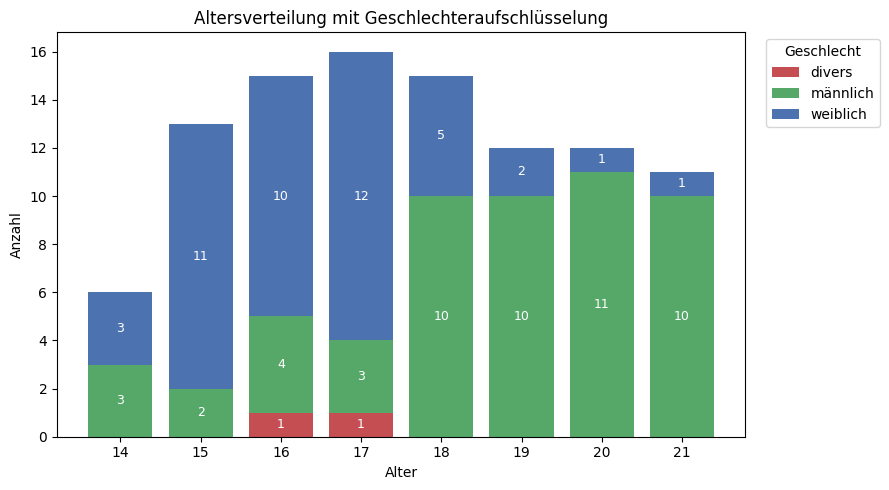

In [ ]:
# Altersverteilung mit Geschlechteraufschlüsselung visualisieren: 
# gestapeltes Balkendiagramm mit Alter auf der x-Achse, Anzahl auf der y-Achse und unterschiedlichen Farben für die Geschlechter
# Kreuztabelle: Alter × Geschlecht
ct = pd.crosstab(df["Alter"].astype(int), df["Geschlecht"])
ct = ct.reindex(age_index, fill_value=0)

# Farben für Geschlechter (anpassen falls nötig)
palette = {"weiblich":"#4C72B0","männlich":"#55A868","divers":"#C44E52","keine Angabe":"#8172B2"}
# Sicherstellen, dass alle Spalten Farben haben
for col in ct.columns:
    if col not in palette:
        palette[col] = None
colors = [palette[c] for c in ct.columns]

# Plot gestapelt
fig, ax = plt.subplots(figsize=(9,5))
bottom = pd.Series([0]*len(ct), index=ct.index)
for i, col in enumerate(ct.columns):
    ax.bar(ct.index, ct[col], bottom=bottom, label=col, color=colors[i])
    bottom += ct[col]

ax.set_xlabel("Alter")
ax.set_ylabel("Anzahl")
ax.set_title("Altersverteilung mit Geschlechteraufschlüsselung")
ax.set_xticks(age_index)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Werte in Segmenten (nur wenn Segmenthöhe > 0)
for age in ct.index:
    cum = 0
    for col in ct.columns:
        val = ct.loc[age, col]
        if val > 0:
            y = cum + val/2
            ax.text(age, y, str(val), ha="center", va="center", fontsize=9, color="white")
            cum += val

ax.legend(title="Geschlecht", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

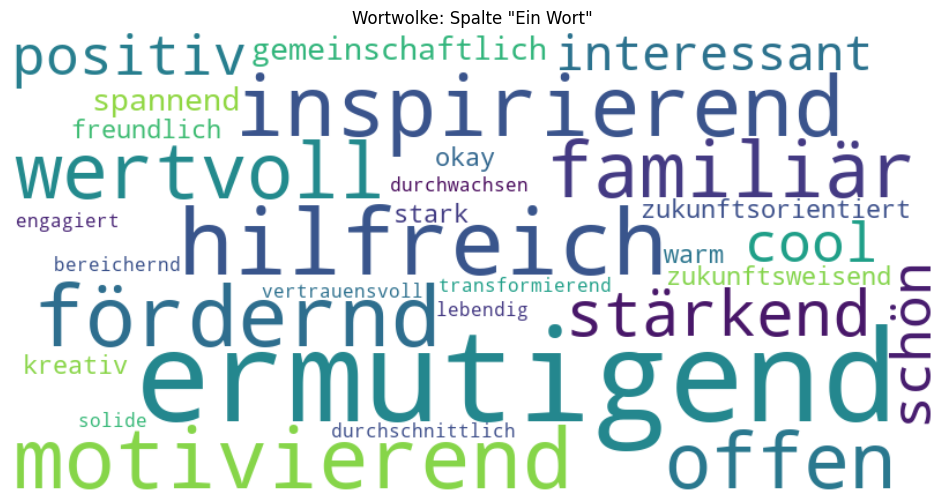

In [ ]:
# Wie nehmen Teilnehmende das Mentoringprogramm wahr?
# Wortwolke für die Spalte "Ein Wort" erstellen

wc = WordCloud(width=800, height=400, background_color="white", collocations=False).generate(" ".join(df["Ein Wort"].dropna()))

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title('Wortwolke: Spalte "Ein Wort"')
plt.show()
